# 05 - LSTM v1.3: secuencias fav/dog sobre matches_features_v2.csv

**Semana 2 (cierre) — Lulu**

Reentrenamiento completo de la LSTM usando el dataset mejorado por Juanfe (`matches_features_v2.csv`, 43,816 x 80):

- Orientación **favorito/no favorito** (`fav_*`/`dog_*`, via Elo) en vez de `home_*`/`away_*` -> tiene sentido en sede neutral (la mayoria de partidos del Mundial).
- Target nuevo: **`target_1x2_fav_dog`** (`fav_win`/`draw`/`dog_win`) en vez de `result`.
- Los 481 partidos de Mundial que antes estaban `pending_feature_engineering=1` ya tienen `fav_form_*`/`dog_form_*` calculados (354/481 con historial; el resto son debuts de seleccion).
- Se reentrena **completo** (no incremental): insertar esos 481 partidos en la linea temporal de cada seleccion cambia las ventanas de "ultimos N partidos" para muchos partidos posteriores.

Arquitectura: se mantiene la misma de v1.2 (2 ramas LSTM + rama de contexto del partido actual), para que la comparacion v1.2 vs v1.3 aisle el efecto del dataset, no de la arquitectura.

## Contenido
1. Carga y exploracion de `matches_features_v2.csv`
2. Guardar metricas de v1.2 (punto de comparacion)
3. Construccion del historial por equipo (fav/dog -> perspectiva por equipo)
4. Construccion de secuencias (ventanas deslizantes)
5. Split temporal train/test
6. Encoding y escalado
7. Arquitectura LSTM (igual a v1.2)
8. Entrenamiento v1.3
9. Evaluacion: v1.2 vs v1.3

## 1. Carga y exploración de `matches_features_v2.csv`

In [10]:
import pandas as pd
import numpy as np
import os

BASE_DIR = os.path.dirname(os.getcwd())  # asume notebook en notebooks/, sube a la raiz
DATA_PROCESSED = os.path.join(BASE_DIR, 'data', 'processed')
MODELS_DIR = os.path.join(BASE_DIR, 'models')
os.makedirs(MODELS_DIR, exist_ok=True)

df = pd.read_csv(os.path.join(DATA_PROCESSED, 'matches_features_v2.csv'), low_memory=False)
df['_date'] = pd.to_datetime(df['_date'])
df = df.sort_values('_date').reset_index(drop=True)

print("Shape:", df.shape)
print("Rango de fechas:", df['_date'].min().date(), "->", df['_date'].max().date())
print("\nDistribucion de target_1x2_fav_dog:")
print(df['target_1x2_fav_dog'].value_counts())

Shape: (43816, 95)
Rango de fechas: 1872-11-30 -> 2026-06-27

Distribucion de target_1x2_fav_dog:
target_1x2_fav_dog
fav_win    23959
draw       10291
dog_win     9440
Name: count, dtype: int64


In [11]:
# Filas usables: deben tener fav_team/dog_team definidos (requiere Elo disponible)
# y target_1x2_fav_dog no nulo
df_seq = df[df['fav_team'].notna() & df['dog_team'].notna() & df['target_1x2_fav_dog'].notna()].copy()

print(f"Total filas: {len(df)}")
print(f"Filas usables (con fav/dog y target definidos): {len(df_seq)}")
print(f"Excluidas (sin Elo): {len(df) - len(df_seq)}")

print("\nNulos en columnas de forma (fav/dog):")
print(df_seq[['fav_form_scored','fav_form_conceded','fav_form_win_rate',
              'dog_form_scored','dog_form_conceded','dog_form_win_rate']].isna().sum())

Total filas: 43816
Filas usables (con fav/dog y target definidos): 43690
Excluidas (sin Elo): 126

Nulos en columnas de forma (fav/dog):
fav_form_scored      92
fav_form_conceded    92
fav_form_win_rate    92
dog_form_scored      91
dog_form_conceded    91
dog_form_win_rate    90
dtype: int64


## 2. Guardar métricas de v1.2 (punto de comparación)

Antes de reentrenar, guardamos las metricas ya obtenidas de v1.2 (sobre `matches_clean.csv`, target `result`, orientacion home/away) en un JSON versionado. Esto permite comparar v1.2 vs v1.3 en la seccion de evaluacion del informe.

In [12]:
import json

# Resultados ya obtenidos para v1.2 (LSTM + class_weight + elo_diff actual, sobre matches_clean.csv)
metrics_v12 = {
    "version": "v1.2",
    "dataset": "matches_clean.csv",
    "target": "result (home_win/draw/away_win)",
    "n_muestras": 42600,
    "n_train": 34080,
    "n_test": 8520,
    "baseline_accuracy": 0.5623,
    "accuracy": 0.580,
    "macro_f1": 0.52,
    "f1_por_clase": {"away_win": 0.53, "draw": 0.33, "home_win": 0.72},
    "notas": "Excluye 481 partidos de Mundial con pending_feature_engineering=1. Orientacion home/away sin sentido en sede neutral."
}

out_path = os.path.join(MODELS_DIR, 'lstm_v1.2_metrics.json')
with open(out_path, 'w', encoding='utf-8') as f:
    json.dump(metrics_v12, f, ensure_ascii=False, indent=2)

print(f"Guardado: {out_path}")
print(json.dumps(metrics_v12, indent=2, ensure_ascii=False))

Guardado: c:\ultimo-proyecto-ia\football-analytics-2026\models\lstm_v1.2_metrics.json
{
  "version": "v1.2",
  "dataset": "matches_clean.csv",
  "target": "result (home_win/draw/away_win)",
  "n_muestras": 42600,
  "n_train": 34080,
  "n_test": 8520,
  "baseline_accuracy": 0.5623,
  "accuracy": 0.58,
  "macro_f1": 0.52,
  "f1_por_clase": {
    "away_win": 0.53,
    "draw": 0.33,
    "home_win": 0.72
  },
  "notas": "Excluye 481 partidos de Mundial con pending_feature_engineering=1. Orientacion home/away sin sentido en sede neutral."
}


## 3. Construcción del historial por equipo (fav/dog -> perspectiva por equipo)

Igual que en v1.2, convertimos el dataset a "un partido-equipo = una fila", pero ahora desde la perspectiva `fav`/`dog` (no `home`/`away`). Para cada equipo, guardamos sus metricas propias (goles a favor/contra, puntos, forma) sin importar si jugo como favorito o no favorito en ese partido -- lo que importa para el historial de un equipo es SU rendimiento, no su rol en cada partido especifico.

`fav_dog_elo_diff` es siempre >= 0 por construccion (elo_fav - elo_dog). Para la perspectiva de cada equipo guardamos `elo_diff_team` con signo: positivo si el equipo era favorito en ese partido, negativo si era el no favorito.

In [13]:
# Perspectiva del equipo FAVORITO en cada partido
fav = df_seq[['_date','fav_team','dog_team','fav_goals','dog_goals','target_1x2_fav_dog','fav_dog_elo_diff',
              'fav_form_scored','fav_form_conceded','fav_form_win_rate','is_world_cup','key']].copy()
fav = fav.rename(columns={
    'fav_team':'team','dog_team':'opponent',
    'fav_goals':'goals_for','dog_goals':'goals_against',
    'fav_form_scored':'form_scored','fav_form_conceded':'form_conceded',
    'fav_form_win_rate':'form_win_rate'
})
fav['era_favorito'] = 1
fav['elo_diff_team'] = fav['fav_dog_elo_diff']  # positivo: era favorito
fav['points'] = fav['target_1x2_fav_dog'].map({'fav_win':3,'draw':1,'dog_win':0})

# Perspectiva del equipo NO FAVORITO (dog) en cada partido
dog = df_seq[['_date','dog_team','fav_team','dog_goals','fav_goals','target_1x2_fav_dog','fav_dog_elo_diff',
              'dog_form_scored','dog_form_conceded','dog_form_win_rate','is_world_cup','key']].copy()
dog = dog.rename(columns={
    'dog_team':'team','fav_team':'opponent',
    'dog_goals':'goals_for','fav_goals':'goals_against',
    'dog_form_scored':'form_scored','dog_form_conceded':'form_conceded',
    'dog_form_win_rate':'form_win_rate'
})
dog['era_favorito'] = 0
dog['elo_diff_team'] = -dog['fav_dog_elo_diff']  # negativo: era no favorito
dog['points'] = dog['target_1x2_fav_dog'].map({'dog_win':3,'draw':1,'fav_win':0})

fav = fav.drop(columns=['fav_dog_elo_diff'])
dog = dog.drop(columns=['fav_dog_elo_diff'])

team_history = pd.concat([fav, dog], ignore_index=True)
team_history = team_history.sort_values(['team','_date']).reset_index(drop=True)

print("team_history shape:", team_history.shape)
team_history[team_history['team']=='Argentina'].tail(5)[
    ['_date','opponent','goals_for','goals_against','points','era_favorito','elo_diff_team','form_scored']
]

team_history shape: (87380, 14)


,_date,opponent,goals_for,goals_against,points,era_favorito,elo_diff_team,form_scored
3113,2025-10-14,Puerto Rico,6.0,0.0,3,1,696.080947,1.900000
3114,2025-11-14,Angola,2.0,0.0,3,1,449.357111,1.900000
3115,2026-06-16,Algeria,NaN,NaN,1,1,387.000000,2.000000
3116,2026-06-22,Austria,NaN,NaN,1,1,295.000000,2.111111
3117,2026-06-27,Jordan,NaN,NaN,1,1,426.000000,2.250000


## 4. Construcción de secuencias (ventanas deslizantes)

Misma logica que v1.2: para cada partido, secuencia de los ultimos `N_STEPS` partidos de cada equipo (favorito y no favorito) ANTES de la fecha del partido actual, sin leakage. Se agrega `era_favorito` como feature de secuencia (antes era `is_home`).

`X_match` ahora contiene `fav_dog_elo_diff` (siempre >= 0) del partido actual -- la magnitud de la diferencia de fortaleza, sin importar de que lado este.

In [14]:
SEQ_FEATURES = ['goals_for','goals_against','points','elo_diff_team',
                'form_scored','form_conceded','form_win_rate','era_favorito','is_world_cup']

N_STEPS = 10
MIN_HISTORY = 5


def construir_secuencias_v13(df_seq, team_history, seq_features, n_steps=10, min_history=5):
    """
    Para cada partido en df_seq construye:
      - X_fav: secuencia (n_steps, n_features) del equipo FAVORITO
      - X_dog: secuencia (n_steps, n_features) del equipo NO FAVORITO
      - X_match: [fav_dog_elo_diff] del partido actual
      - y: target_1x2_fav_dog del partido actual
      - meta: fecha, equipos y key (trazabilidad / split temporal)
    """
    th_indexed = {team: g.reset_index(drop=True) for team, g in team_history.groupby('team')}

    X_fav_list, X_dog_list, X_match_list, y_list, meta_list = [], [], [], [], []

    for _, row in df_seq.iterrows():
        date = row['_date']
        fav_team, dog_team = row['fav_team'], row['dog_team']

        seq_f, seq_d = None, None

        if fav_team in th_indexed:
            past_f = th_indexed[fav_team]
            past_f = past_f[past_f['_date'] < date]
            if len(past_f) >= min_history:
                last_f = past_f.tail(n_steps)[seq_features].values
                if len(last_f) < n_steps:
                    pad = np.zeros((n_steps - len(last_f), len(seq_features)))
                    last_f = np.vstack([pad, last_f])
                seq_f = last_f

        if dog_team in th_indexed:
            past_d = th_indexed[dog_team]
            past_d = past_d[past_d['_date'] < date]
            if len(past_d) >= min_history:
                last_d = past_d.tail(n_steps)[seq_features].values
                if len(last_d) < n_steps:
                    pad = np.zeros((n_steps - len(last_d), len(seq_features)))
                    last_d = np.vstack([pad, last_d])
                seq_d = last_d

        if seq_f is not None and seq_d is not None:
            X_fav_list.append(seq_f)
            X_dog_list.append(seq_d)
            X_match_list.append([row['fav_dog_elo_diff']])
            y_list.append(row['target_1x2_fav_dog'])
            meta_list.append({'date': date, 'fav_team': fav_team, 'dog_team': dog_team, 'key': row['key']})

    X_fav = np.array(X_fav_list, dtype=np.float32)
    X_dog = np.array(X_dog_list, dtype=np.float32)
    X_match = np.array(X_match_list, dtype=np.float32)
    y = np.array(y_list)
    meta = pd.DataFrame(meta_list)

    return X_fav, X_dog, X_match, y, meta


X_fav, X_dog, X_match, y, meta = construir_secuencias_v13(df_seq, team_history, SEQ_FEATURES, N_STEPS, MIN_HISTORY)

print("X_fav shape:", X_fav.shape)
print("X_dog shape:", X_dog.shape)
print("X_match shape:", X_match.shape)
print("Nulos en X_match:", np.isnan(X_match).sum())
print("\nDistribucion de y:")
print(pd.Series(y).value_counts())
print("\nComparacion con v1.2: 42,600 muestras (v1.2) vs", len(y), "muestras (v1.3)")
X_fav, X_dog, X_match, y, meta = construir_secuencias_v13(df_seq, team_history, SEQ_FEATURES, N_STEPS, MIN_HISTORY)

# --- DIAGNÓSTICO NUEVO (agregar aquí) ---
print("\n--- DIAGNÓSTICO NaNs ---")
print("NaNs en X_fav:", np.isnan(X_fav).sum())
print("NaNs en X_dog:", np.isnan(X_dog).sum())
print("NaNs en X_match:", np.isnan(X_match).sum())
print("\nNulos por feature en team_history:")
print(team_history[SEQ_FEATURES].isna().sum())
print("\nValores únicos de era_favorito:", team_history['era_favorito'].unique())
# -----------------------------------------

print("\nX_fav shape:", X_fav.shape)
print("X_dog shape:", X_dog.shape)
print("X_match shape:", X_match.shape)
print("Nulos en X_match:", np.isnan(X_match).sum())
print("\nDistribucion de y:")
print(pd.Series(y).value_counts())
print("\nComparacion con v1.2: 42,600 muestras (v1.2) vs", len(y), "muestras (v1.3)")
# Imputar NaNs en X_fav y X_dog con 0 antes de escalar
# (0 es neutro para variables centradas: goles, forma, etc.)
X_fav = np.nan_to_num(X_fav, nan=0.0)
X_dog = np.nan_to_num(X_dog, nan=0.0)

print("NaNs en X_fav después de imputación:", np.isnan(X_fav).sum())
print("NaNs en X_dog después de imputación:", np.isnan(X_dog).sum())
print("Todo OK para continuar ✅")

X_fav shape: (42943, 10, 9)
X_dog shape: (42943, 10, 9)
X_match shape: (42943, 1)
Nulos en X_match: 0

Distribucion de y:
fav_win    23577
draw       10189
dog_win     9177
Name: count, dtype: int64

Comparacion con v1.2: 42,600 muestras (v1.2) vs 42943 muestras (v1.3)

--- DIAGNÓSTICO NaNs ---
NaNs en X_fav: 1049
NaNs en X_dog: 2006
NaNs en X_match: 0

Nulos por feature en team_history:
goals_for         94
goals_against     94
points             0
elo_diff_team      0
form_scored      183
form_conceded    183
form_win_rate    182
era_favorito       0
is_world_cup       0
dtype: int64

Valores únicos de era_favorito: [0 1]

X_fav shape: (42943, 10, 9)
X_dog shape: (42943, 10, 9)
X_match shape: (42943, 1)
Nulos en X_match: 0

Distribucion de y:
fav_win    23577
draw       10189
dog_win     9177
Name: count, dtype: int64

Comparacion con v1.2: 42,600 muestras (v1.2) vs 42943 muestras (v1.3)
NaNs en X_fav después de imputación: 0
NaNs en X_dog después de imputación: 0
Todo OK para contin

## 5. Split temporal train/test

Igual que v1.2: 80/20 cronologico, sin shuffle.

In [15]:
meta_sorted_idx = meta.sort_values('date').index.values
split_idx = int(len(meta_sorted_idx) * 0.8)
train_idx, test_idx = meta_sorted_idx[:split_idx], meta_sorted_idx[split_idx:]

X_fav_train, X_fav_test = X_fav[train_idx], X_fav[test_idx]
X_dog_train, X_dog_test = X_dog[train_idx], X_dog[test_idx]
X_match_train, X_match_test = X_match[train_idx], X_match[test_idx]
y_train, y_test = y[train_idx], y[test_idx]

# Imputar posibles NaN remanentes en X_match (deberia ser 0, ya verificado en seccion 4)
X_match_train = np.nan_to_num(X_match_train, nan=0.0)
X_match_test = np.nan_to_num(X_match_test, nan=0.0)

print(f"Train: {len(train_idx)} partidos ({meta.loc[train_idx,'date'].min().date()} -> {meta.loc[train_idx,'date'].max().date()})")
print(f"Test:  {len(test_idx)} partidos ({meta.loc[test_idx,'date'].min().date()} -> {meta.loc[test_idx,'date'].max().date()})")

Train: 34354 partidos (1877-03-03 -> 2015-06-05)
Test:  8589 partidos (2015-06-05 -> 2026-06-27)


## 6. Encoding del target y escalado de features

`target_1x2_fav_dog` tiene 3 clases (`fav_win`/`draw`/`dog_win`). Aplicamos `class_weight` balanceado, igual que en v1.2 (la version que mejor predijo las 3 clases).

In [ ]:
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.utils.class_weight import compute_class_weight

# --- Target ---
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc = le.transform(y_test)
print("Clases (orden del encoding):", list(le.classes_))

# --- class_weight (igual que v1.2) ---
# Pesos suavizados: mitad del camino entre balanced y uniforme
clases = np.unique(y_train_enc)
weights_balanced = compute_class_weight('balanced', classes=clases, y=y_train_enc)

# Factor de suavizado: 0.5 = mitad del efecto de balanced, 0 = sin peso, 1 = balanced completo
alpha = 0.5
weights_suavizados = 1 + alpha * (weights_balanced - 1)
class_weight_dict = dict(zip(clases, weights_suavizados))

print("Pesos balanceados:", dict(zip(clases, weights_balanced.round(3))))
print("Pesos suavizados (alpha=0.5):", {k: round(v, 3) for k, v in class_weight_dict.items()})
print("Mapeo clases:", dict(zip(le.classes_, [round(class_weight_dict[i], 3) for i in range(len(le.classes_))])))

# --- Features de secuencia ---
n_features = X_fav_train.shape[2]
scaler = StandardScaler()
scaler.fit(X_fav_train.reshape(-1, n_features))

def escalar(X, scaler, n_features):
    shape = X.shape
    return scaler.transform(X.reshape(-1, n_features)).reshape(shape)

X_fav_train_s = escalar(X_fav_train, scaler, n_features)
X_fav_test_s = escalar(X_fav_test, scaler, n_features)
X_dog_train_s = escalar(X_dog_train, scaler, n_features)
X_dog_test_s = escalar(X_dog_test, scaler, n_features)

# --- Feature de contexto del partido (fav_dog_elo_diff) ---
scaler_match = StandardScaler()
scaler_match.fit(X_match_train)
X_match_train_s = scaler_match.transform(X_match_train)
X_match_test_s = scaler_match.transform(X_match_test)

print("\nX_fav_train_s shape:", X_fav_train_s.shape)
print("X_match_train_s shape:", X_match_train_s.shape)

Clases (orden del encoding): [np.str_('dog_win'), np.str_('draw'), np.str_('fav_win')]

Pesos por clase: {np.int64(0): np.float64(1.5041814440211918), np.int64(1): np.float64(1.4149676675316116), np.int64(2): np.float64(0.614078364078364)}
Mapeo: {np.str_('dog_win'): np.float64(1.5041814440211918), np.str_('draw'): np.float64(1.4149676675316116), np.str_('fav_win'): np.float64(0.614078364078364)}

X_fav_train_s shape: (34354, 10, 9)
X_match_train_s shape: (34354, 1)


In [17]:
# Baseline: predecir siempre la clase mayoritaria
mayoria = pd.Series(y_train).value_counts().idxmax()
baseline_acc = (y_test == mayoria).mean()
print(f"Baseline (predecir siempre '{mayoria}'): accuracy = {baseline_acc:.4f}")
print("\nNota: fav_win deberia ser mas frecuente que home_win en v1.2 (el favorito por Elo gana mas seguido")
print("que el 'home' arbitrario de sede neutral), por lo que este baseline puede ser mas alto que el de v1.2 (0.5623).")

Baseline (predecir siempre 'fav_win'): accuracy = 0.5739

Nota: fav_win deberia ser mas frecuente que home_win en v1.2 (el favorito por Elo gana mas seguido
que el 'home' arbitrario de sede neutral), por lo que este baseline puede ser mas alto que el de v1.2 (0.5623).


In [18]:
print("np.unique(y_train_enc):", np.unique(y_train_enc))
print("le.classes_:", le.classes_)
print("class_weight_dict:", class_weight_dict)

# Verificación cruzada: distribución real de y_train
import collections
print("\nDistribución y_train (texto):", collections.Counter(y_train))
print("Distribución y_train_enc (numérico):", collections.Counter(y_train_enc))

np.unique(y_train_enc): [0 1 2]
le.classes_: ['dog_win' 'draw' 'fav_win']
class_weight_dict: {np.int64(0): np.float64(1.5041814440211918), np.int64(1): np.float64(1.4149676675316116), np.int64(2): np.float64(0.614078364078364)}

Distribución y_train (texto): Counter({np.str_('fav_win'): 18648, np.str_('draw'): 8093, np.str_('dog_win'): 7613})
Distribución y_train_enc (numérico): Counter({np.int64(2): 18648, np.int64(1): 8093, np.int64(0): 7613})


## 7. Arquitectura LSTM (igual a v1.2)

Misma arquitectura: dos ramas LSTM (favorito / no favorito) + rama de contexto (`fav_dog_elo_diff`) -> concat -> densas -> softmax 3 clases.

In [19]:
import tensorflow as tf
from tensorflow.keras import layers, models

print("TensorFlow:", tf.__version__)

n_steps = X_fav_train_s.shape[1]
n_features = X_fav_train_s.shape[2]
n_classes = len(le.classes_)

input_fav = layers.Input(shape=(n_steps, n_features), name='input_fav')
input_dog = layers.Input(shape=(n_steps, n_features), name='input_dog')
input_match = layers.Input(shape=(X_match_train_s.shape[1],), name='input_match')

lstm_fav = layers.LSTM(32, name='lstm_fav')(input_fav)
lstm_dog = layers.LSTM(32, name='lstm_dog')(input_dog)

concat = layers.Concatenate()([lstm_fav, lstm_dog, input_match])
x = layers.Dense(32, activation='relu')(concat)
x = layers.Dropout(0.3)(x)
x = layers.Dense(16, activation='relu')(x)
output = layers.Dense(n_classes, activation='softmax', name='output')(x)

model = models.Model(inputs=[input_fav, input_dog, input_match], outputs=output)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

TensorFlow: 2.21.0


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_fav           │ (None, 10, 9)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_dog           │ (None, 10, 9)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_fav (LSTM)     │ (None, 32)        │      5,376 │ input_fav[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_dog (LSTM)     │ (None, 32)        │      5,376 │ input_dog[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_match         │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 65)        │          0 │ lstm_fav[0][0],   │
│ (Concatenate)       │                   │            │ lstm_dog[0][0],   │
│                     │                   │            │ input_match[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 32)        │      2,112 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 32)        │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 16)        │        528 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output (Dense)      │ (None, 3)         │         51 │ dense_1[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 13,443 (52.51 KB)

 Trainable params: 13,443 (52.51 KB)

 Non-trainable params: 0 (0.00 B)

## 8. Entrenamiento v1.3

In [20]:
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=5, restore_best_weights=True
)

history = model.fit(
    [X_fav_train_s, X_dog_train_s, X_match_train_s], y_train_enc,
    validation_data=([X_fav_test_s, X_dog_test_s, X_match_test_s], y_test_enc),
    epochs=30,
    batch_size=64,
    callbacks=[early_stop],
    class_weight=class_weight_dict,
    verbose=1
)

Epoch 1/30
537/537 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - accuracy: 0.4297 - loss: 1.0659 - val_accuracy: 0.4684 - val_loss: 1.0118
Epoch 2/30
537/537 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.4461 - loss: 1.0502 - val_accuracy: 0.4746 - val_loss: 1.0096
Epoch 3/30
537/537 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.4471 - loss: 1.0480 - val_accuracy: 0.4815 - val_loss: 0.9968
Epoch 4/30
537/537 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.4484 - loss: 1.0458 - val_accuracy: 0.4813 - val_loss: 0.9966
Epoch 5/30
537/537 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.4480 - loss: 1.0435 - val_accuracy: 0.4774 - val_loss: 1.0011
Epoch 6/30
537/537 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.4461 - loss: 1.0418 - val_accuracy: 0.4906 - val_loss: 0.9787
Epoch 7/30
537/537 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.4510 - loss: 1.0406 - val_accuracy: 0.4666 - val_loss: 1.0067
Epoch 8/30
537/537 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.4507 - loss: 1.0397 - val_accuracy: 0.

## 9. Evaluación: v1.2 vs v1.3

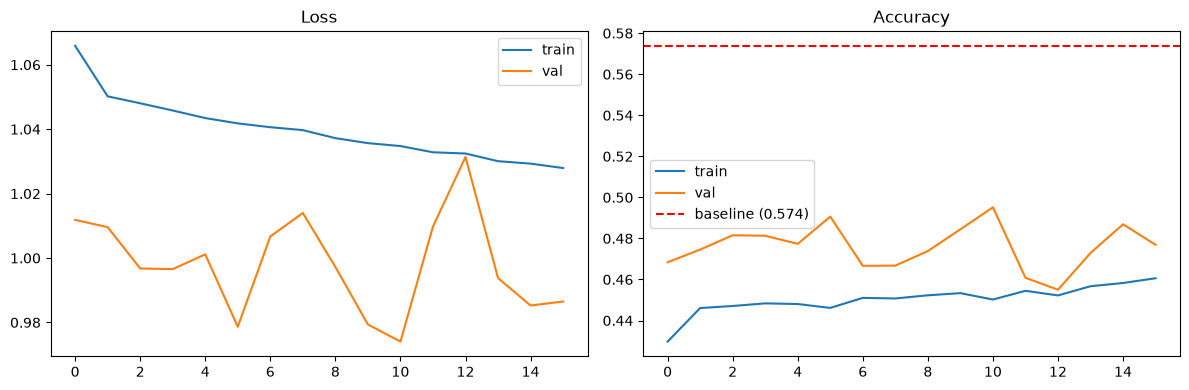

In [21]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history.history['loss'], label='train')
axes[0].plot(history.history['val_loss'], label='val')
axes[0].set_title('Loss')
axes[0].legend()

axes[1].plot(history.history['accuracy'], label='train')
axes[1].plot(history.history['val_accuracy'], label='val')
axes[1].axhline(baseline_acc, color='red', linestyle='--', label=f'baseline ({baseline_acc:.3f})')
axes[1].set_title('Accuracy')
axes[1].legend()
plt.tight_layout()
plt.show()

In [22]:
from sklearn.metrics import classification_report, confusion_matrix, f1_score

y_pred_proba = model.predict([X_fav_test_s, X_dog_test_s, X_match_test_s])
y_pred = y_pred_proba.argmax(axis=1)

acc_v13 = (y_pred == y_test_enc).mean()
macro_f1_v13 = f1_score(y_test_enc, y_pred, average='macro')

print("Accuracy LSTM v1.3:", round(acc_v13, 4))
print("Accuracy baseline:", round(baseline_acc, 4))
print("Macro F1 v1.3:", round(macro_f1_v13, 4))

print("\nClassification report:")
print(classification_report(y_test_enc, y_pred, target_names=le.classes_))

print("Matriz de confusion:")
print(pd.DataFrame(
    confusion_matrix(y_test_enc, y_pred),
    index=[f'real_{c}' for c in le.classes_],
    columns=[f'pred_{c}' for c in le.classes_]
))

269/269 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
Accuracy LSTM v1.3: 0.4952
Accuracy baseline: 0.5739
Macro F1 v1.3: 0.4273

Classification report:
              precision    recall  f1-score   support

     dog_win       0.30      0.40      0.34      1564
        draw       0.28      0.29      0.29      2096
     fav_win       0.70      0.61      0.65      4929

    accuracy                           0.50      8589
   macro avg       0.43      0.44      0.43      8589
weighted avg       0.52      0.50      0.51      8589

Matriz de confusion:
              pred_dog_win  pred_draw  pred_fav_win
real_dog_win           631        476           457
real_draw              641        610           845
real_fav_win           826       1091          3012


In [23]:
# Tabla comparativa v1.2 vs v1.3
f1_por_clase_v13 = f1_score(y_test_enc, y_pred, average=None)
f1_dict_v13 = dict(zip(le.classes_, [round(x, 2) for x in f1_por_clase_v13]))

comparativa = pd.DataFrame({
    'metrica': ['dataset', 'n_muestras', 'baseline_accuracy', 'accuracy', 'macro_f1'],
    'v1.2': ['matches_clean.csv', 42600, 0.5623, 0.580, 0.52],
    'v1.3': ['matches_features_v2.csv', len(y), round(baseline_acc, 4), round(acc_v13, 4), round(macro_f1_v13, 4)]
})
print(comparativa.to_string(index=False))
print("\nF1 por clase v1.2:", {"away_win/dog_win": 0.53, "draw": 0.33, "home_win/fav_win": 0.72})
print("F1 por clase v1.3:", f1_dict_v13)

          metrica              v1.2                    v1.3
          dataset matches_clean.csv matches_features_v2.csv
       n_muestras             42600                   42943
baseline_accuracy            0.5623                  0.5739
         accuracy              0.58                  0.4952
         macro_f1              0.52                  0.4273

F1 por clase v1.2: {'away_win/dog_win': 0.53, 'draw': 0.33, 'home_win/fav_win': 0.72}
F1 por clase v1.3: {np.str_('dog_win'): np.float64(0.34), np.str_('draw'): np.float64(0.29), np.str_('fav_win'): np.float64(0.65)}


In [24]:
# Guardar modelo, artefactos y metricas de v1.3
model.save(os.path.join(MODELS_DIR, 'lstm_1x2_fav_dog_v1.3.keras'))

import joblib
joblib.dump(scaler, os.path.join(MODELS_DIR, 'lstm_v1.3_scaler.joblib'))
joblib.dump(scaler_match, os.path.join(MODELS_DIR, 'lstm_v1.3_scaler_match.joblib'))
joblib.dump(le, os.path.join(MODELS_DIR, 'lstm_v1.3_labelencoder.joblib'))

metrics_v13 = {
    "version": "v1.3",
    "dataset": "matches_features_v2.csv",
    "target": "target_1x2_fav_dog (fav_win/draw/dog_win)",
    "n_muestras": int(len(y)),
    "n_train": int(len(train_idx)),
    "n_test": int(len(test_idx)),
    "baseline_accuracy": round(float(baseline_acc), 4),
    "accuracy": round(float(acc_v13), 4),
    "macro_f1": round(float(macro_f1_v13), 4),
    "f1_por_clase": {k: float(v) for k, v in f1_dict_v13.items()},
    "notas": "Incluye los 481 partidos de Mundial (354 con forma calculada). Orientacion fav/dog via Elo, valida en sede neutral."
}

with open(os.path.join(MODELS_DIR, 'lstm_v1.3_metrics.json'), 'w', encoding='utf-8') as f:
    json.dump(metrics_v13, f, ensure_ascii=False, indent=2)

print("Modelo y metricas v1.3 guardados en", MODELS_DIR)

Modelo y metricas v1.3 guardados en c:\ultimo-proyecto-ia\football-analytics-2026\models


## Notas y próximos pasos

- **v1.3 es comparable con v1.2** en arquitectura (misma estructura de 2 ramas LSTM + contexto), cambia el dataset (incluye los 481 partidos de Mundial completos) y la orientacion (fav/dog vs home/away). Esto aisla el efecto del dataset mejorado.
- Si el baseline de v1.3 (clase mayoritaria `fav_win`) es mas alto que el de v1.2 (`home_win`, 0.5623), es esperado: el favorito por Elo gana mas seguido que un "local" arbitrario de sede neutral -- la clase mayoritaria es mas "real" ahora.
- **127 de los 481 partidos** de Mundial siguen sin `fav_form_*` (debuts de seleccion, sin historial previo) -- quedan fuera de las secuencias por `min_history=5`, igual que cualquier debut.
- Proximo paso: si el macro F1 se estanca, considerar v1.4 con mas capacidad (LSTM 64 unidades) o `N_STEPS` distinto, como experimento separado y documentado.